# Dropout autoencoder on MNIST — entrenamiento, guardado y visualizaciones

Esta notebook implementa de punta a punta:

- entrenamiento reproducible en GPU de un autoencoder de una capa oculta sobre MNIST
- dos corridas separadas: **sin dropout** y **con dropout p=0.5**
- guardado de artefactos en `runs/autoencoder/hash_de_corrida/model_name/`
- guardado de `metrics.json` con hiperparámetros y resultados
- funciones desacopladas que reciben **un solo path de modelo** y generan:
  - visualización de **coadaptation** (mosaico de features aprendidas)
  - visualización de **representational sparsity** siguiendo el procedimiento del paper

La parte de sparsity replica el procedimiento descrito por Srivastava et al.: se toma **un minibatch aleatorio del test set**, se computan las activaciones ocultas de ese minibatch, y se grafican dos histogramas: **(1)** media de activación por unidad oculta sobre el minibatch y **(2)** todas las activaciones del mismo minibatch.

In [1]:
# =========================
# 0) Reproducibilidad fuerte
# =========================

import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
os.environ.setdefault('PYTHONHASHSEED', '1234')

import random
import math
import json
import time
import hashlib
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Any, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


def seed_everything(seed: int = 1234, deterministic: bool = False) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


SEED = 1234
seed_everything(SEED, deterministic=False)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)
print('torch version =', torch.__version__)
if torch.cuda.is_available():
    print('cuda device =', torch.cuda.get_device_name(0))


DEVICE = cuda
torch version = 2.6.0+cu124
cuda device = NVIDIA GeForce MX230


In [2]:
# =========================
# 1) Configuración general
# =========================

ROOT_RUNS = Path('runs') / 'autoencoder'
ROOT_RUNS.mkdir(parents=True, exist_ok=True)

@dataclass
class RunConfig:
    seed: int = 1234
    dataset_name: str = 'MNIST'
    input_dim: int = 28 * 28
    hidden_dim: int = 256
    hidden_activation: str = 'relu'
    output_activation: str = 'sigmoid'
    dropout_p: float = 0.0
    batch_size: int = 512
    epochs: int = 60
    learning_rate: float = 1e-3
    optimizer: str = 'Adam'
    loss_name: str = 'BCE'
    weight_decay: float = 0.0
    use_nesterov: bool = False
    num_workers: int = 4
    pin_memory: bool = True
    save_every_epoch: bool = False
    model_name: str = 'baseline'


def stable_run_hash(config: RunConfig, extra: Optional[Dict[str, Any]] = None) -> str:
    payload = asdict(config).copy()
    if extra is not None:
        payload['extra'] = extra
    encoded = json.dumps(payload, sort_keys=True, ensure_ascii=True).encode('utf-8')
    return hashlib.sha256(encoded).hexdigest()[:12]


In [3]:
# =========================
# 2) Datos MNIST
# =========================

transform = transforms.Compose([
    transforms.ToTensor(),
])


def build_datasets(data_root: str = './data'):
    train_ds = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
    test_ds = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)
    return train_ds, test_ds


def build_dataloaders(batch_size: int = 512, num_workers: int = 0, pin_memory: bool = True):
    train_ds, test_ds = build_datasets()
    generator = torch.Generator()
    generator.manual_seed(SEED)
    train_loader = DataLoader(
        train_ds,
        batch_size=512,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
    )
    
    test_loader = DataLoader(
        test_ds,
        batch_size=1024,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
    )
    return train_loader, test_loader


train_loader, test_loader = build_dataloaders(batch_size=512)
print('train batches =', len(train_loader), '| test batches =', len(test_loader))


train batches = 118 | test batches = 10


In [4]:
# =========================
# 3) Modelo: autoencoder 784 -> 256 -> 784
# =========================

class OneHiddenLayerAutoencoder(nn.Module):
    def __init__(self, input_dim: int = 784, hidden_dim: int = 256, dropout_p: float = 0.0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.dropout_p = dropout_p
        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(p=dropout_p)
        self.decoder = nn.Linear(hidden_dim, input_dim)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.encoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.xavier_uniform_(self.decoder.weight)
        nn.init.zeros_(self.decoder.bias)

    def encode_pre_dropout(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        h = F.relu(self.encoder(x))
        return h

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encode_pre_dropout(x)
        h = self.dropout(h)
        return h

    def decode_logits(self, h: torch.Tensor) -> torch.Tensor:
        return self.decoder(h)

    def decode(self, h: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.decode_logits(h))

    def forward(self, x: torch.Tensor):
        x = x.view(x.size(0), -1)
        h = self.encode_pre_dropout(x)
        h_drop = self.dropout(h)
        logits = self.decode_logits(h_drop)
        recon = torch.sigmoid(logits)
        return recon, logits, h


In [5]:
# =========================
# 4) Utilidades de entrenamiento y guardado
# =========================

def reconstruction_bce_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return F.binary_cross_entropy_with_logits(logits, target, reduction='mean')


@torch.no_grad()
def evaluate_autoencoder(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    total_bce = 0.0
    total_mse = 0.0
    total_items = 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        flat = x.view(x.size(0), -1)
        recon, logits, h = model(x)
        bce = F.binary_cross_entropy_with_logits(logits, flat, reduction='sum')
        mse = F.mse_loss(recon, flat, reduction='sum')
        total_bce += bce.item()
        total_mse += mse.item()
        total_items += x.size(0)
    return {
        'bce_per_example': total_bce / total_items,
        'mse_per_example': total_mse / total_items,
    }


def run_dir_from_config(config: RunConfig) -> Path:
    run_hash = stable_run_hash(config)
    run_dir = ROOT_RUNS / run_hash / config.model_name
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


def save_json(path: Path, payload):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)


def save_checkpoint(path: Path, model: nn.Module, config: RunConfig, epoch: int, metrics):
    ckpt = {
        'model_state_dict': model.state_dict(),
        'config': asdict(config),
        'epoch': epoch,
        'metrics': metrics,
        'torch_version': torch.__version__,
    }
    torch.save(ckpt, path)


def make_optimizer(model: nn.Module, config: RunConfig):
    if config.optimizer.upper() == 'ADAM':
        return torch.optim.Adam(
            model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )
    raise ValueError(f'Optimizer no soportado: {config.optimizer}')


def train_one_model(config: RunConfig) -> Path:
    seed_everything(config.seed, deterministic=False)
    run_dir = run_dir_from_config(config)
    model_path = run_dir / 'model.pt'
    metrics_path = run_dir / 'metrics.json'
    history_path = run_dir / 'history.json'

    train_loader, test_loader = build_dataloaders(
        batch_size=config.batch_size,
        num_workers=config.num_workers,
        pin_memory=config.pin_memory,
    )

    model = OneHiddenLayerAutoencoder(
        input_dim=config.input_dim,
        hidden_dim=config.hidden_dim,
        dropout_p=config.dropout_p,
    ).to(DEVICE)

    optimizer = make_optimizer(model, config)
    history = []
    t0 = time.time()

    for epoch in range(1, config.epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_items = 0
        for x, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            flat = x.view(x.size(0), -1)
            optimizer.zero_grad(set_to_none=True)
            recon, logits, h = model(x)
            loss = reconstruction_bce_loss(logits, flat)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
            epoch_items += x.size(0)

        train_bce = epoch_loss / epoch_items
        row = {'epoch': epoch, 'train_bce_epoch': train_bce}

        should_eval = (epoch == 1) or (epoch % 10 == 0) or (epoch == config.epochs)
        if should_eval:
            eval_train = evaluate_autoencoder(model, train_loader, DEVICE)
            eval_test = evaluate_autoencoder(model, test_loader, DEVICE)
            row.update({
                'train_bce_eval': eval_train['bce_per_example'],
                'train_mse_eval': eval_train['mse_per_example'],
                'test_bce_eval': eval_test['bce_per_example'],
                'test_mse_eval': eval_test['mse_per_example'],
            })
            print(f"[{config.model_name}] epoch={epoch:03d} train_bce={train_bce:.4f} test_bce={eval_test['bce_per_example']:.4f} test_mse={eval_test['mse_per_example']:.4f}")
        history.append(row)
        if config.save_every_epoch:
            save_checkpoint(run_dir / f'model_epoch_{epoch:03d}.pt', model, config, epoch, row)

    total_seconds = time.time() - t0
    last_eval_row = next(row for row in reversed(history) if 'test_bce_eval' in row)
    final_metrics = {
        'train_bce_per_example': last_eval_row['train_bce_eval'],
        'train_mse_per_example': last_eval_row['train_mse_eval'],
        'test_bce_per_example': last_eval_row['test_bce_eval'],
        'test_mse_per_example': last_eval_row['test_mse_eval'],
        'training_seconds': total_seconds,
        'device': str(DEVICE),
    }

    save_checkpoint(model_path, model, config, config.epochs, final_metrics)
    save_json(history_path, {'history': history})
    save_json(metrics_path, {
        'config': asdict(config),
        'final_metrics': final_metrics,
        'paths': {
            'model_path': str(model_path),
            'history_path': str(history_path),
        },
    })
    print(f'Guardado en: {run_dir}')
    return model_path


In [14]:
# =========================
# 5) Carga de modelo desde path
# =========================

def load_model_from_path(model_path: str | Path, map_location=None):
    model_path = Path(model_path)
    if map_location is None:
        map_location = DEVICE
    ckpt = torch.load(model_path, map_location=map_location, weights_only=False)
    config_dict = ckpt['config']
    config = RunConfig(**config_dict)
    model = OneHiddenLayerAutoencoder(
        input_dim=config.input_dim,
        hidden_dim=config.hidden_dim,
        dropout_p=config.dropout_p,
    )
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(DEVICE)
    model.eval()
    return model, config, ckpt


In [20]:
# =========================
# 6) Visualización: coadaptation
# =========================

def _make_weight_grid(weights: np.ndarray, n_cols: int = 16, image_shape=(28, 28), pad: int = 1):
    n_filters = weights.shape[0]
    n_rows = math.ceil(n_filters / n_cols)
    h, w = image_shape
    canvas_h = n_rows * h + (n_rows - 1) * pad
    canvas_w = n_cols * w + (n_cols - 1) * pad
    canvas = np.ones((canvas_h, canvas_w), dtype=np.float32) * 0.5
    for i in range(n_filters):
        r = i // n_cols
        c = i % n_cols
        top = r * (h + pad)
        left = c * (w + pad)
        filt = weights[i].reshape(h, w)
        fmin, fmax = filt.min(), filt.max()
        if fmax > fmin:
            filt = (filt - fmin) / (fmax - fmin)
        else:
            filt = np.zeros_like(filt)
        canvas[top:top+h, left:left+w] = filt
    return canvas


def plot_coadaptation_from_model_path(model_path: str | Path, save_path=None, show: bool = True, figsize=(10, 10)):
    # Replica la visualización tipo Fig. 7.1 / Fig. 2.4 del paper.
    model, config, ckpt = load_model_from_path(model_path)
    weights = model.encoder.weight.detach().cpu().numpy()
    grid = _make_weight_grid(weights, n_cols=16, image_shape=(28, 28), pad=1)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(grid, cmap='gray', interpolation='nearest')
    ax.set_title(f"Visualización de coadaptaciones — {config.model_name} | dropout_p={config.dropout_p}")
    ax.axis('off')
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print('Saved:', save_path)
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


In [18]:
# =========================
# 7) Visualización: representational sparsity
# =========================

def _get_loader(split: str, batch_size: int = 512):
    train_loader, test_loader = build_dataloaders(batch_size=batch_size)
    split = split.lower()
    if split == 'train':
        return train_loader
    if split == 'test':
        return test_loader
    raise ValueError("split debe ser 'train' o 'test'")


@torch.no_grad()
def _collect_hidden_activations_for_batch(model: nn.Module, split: str = 'test', batch_size: int = 512, batch_index: Optional[int] = 0, random_batch: bool = False, seed: int = 1234):
    # Fiel al paper:
    # - minibatch aleatorio del test set
    # - activaciones ocultas del mismo minibatch
    # - sin escalar pesos por dropout en visualización
    loader = _get_loader(split=split, batch_size=batch_size)
    batches = list(loader)
    if random_batch:
        rng = np.random.default_rng(seed)
        idx = int(rng.integers(low=0, high=len(batches)))
    else:
        idx = int(batch_index if batch_index is not None else 0)
    x, _ = batches[idx]
    x = x.to(DEVICE, non_blocking=True)
    model.eval()
    h = model.encode_pre_dropout(x)
    return h.detach().cpu()


def plot_representational_sparsity_from_model_path(model_path: str | Path, split: str = 'test', batch_size: int = 512, batch_index: Optional[int] = None, random_batch: bool = True, seed: int = 1234, bins_mean: int = 60, bins_activation: int = 80, save_path=None, show: bool = True):
    # Replica el procedimiento del paper para sparsity usando un solo modelo.
    model, config, ckpt = load_model_from_path(model_path)
    h = _collect_hidden_activations_for_batch(
        model=model,
        split=split,
        batch_size=batch_size,
        batch_index=batch_index,
        random_batch=random_batch,
        seed=seed,
    )

    mean_per_unit = h.mean(dim=0).numpy()
    all_activations = h.reshape(-1).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(mean_per_unit, bins=bins_mean)
    axes[0].set_title('Activación media')
    axes[0].set_xlabel('Valor de activación')
    axes[0].set_ylabel('Total')

    axes[1].hist(all_activations, bins=bins_activation)
    axes[1].set_title('Activación')
    axes[1].set_xlabel('Valor de activación')
    axes[1].set_ylabel('Total')

    batch_desc = 'minibatch aleatorio' if random_batch else f'batch_index={batch_index}'
    fig.suptitle(f"Esparsidad de la representación — {config.model_name} | dropout_p={config.dropout_p} | {split} | {batch_desc}", y=1.05)
    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print('Saved:', save_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary = {
        'mean_activation_mean': float(mean_per_unit.mean()),
        'mean_activation_std': float(mean_per_unit.std()),
        'all_activation_mean': float(all_activations.mean()),
        'all_activation_std': float(all_activations.std()),
        'fraction_exact_zero': float((all_activations == 0.0).mean()),
        'fraction_gt_1': float((all_activations > 1.0).mean()),
        'fraction_gt_2': float((all_activations > 2.0).mean()),
    }
    print(json.dumps(summary, indent=2))
    return fig, summary


In [9]:
# =========================
# 8) Entrenamiento secuencial: uno por vez
# =========================

baseline_config = RunConfig(
    seed=SEED,
    dropout_p=0.0,
    batch_size=512,
    epochs=60,
    learning_rate=1e-3,
    optimizer='Adam',
    model_name='baseline',
)

dropout_config = RunConfig(
    seed=SEED,
    dropout_p=0.5,
    batch_size=512,
    epochs=60,
    learning_rate=1e-3,
    optimizer='Adam',
    model_name='dropout_p0_5',
)

print('Baseline run dir :', run_dir_from_config(baseline_config))
print('Dropout run dir  :', run_dir_from_config(dropout_config))


Baseline run dir : runs/autoencoder/638d7707aa98/baseline
Dropout run dir  : runs/autoencoder/6fa4a31ed05d/dropout_p0_5


In [10]:
# =========================
# 9) Ejecutar entrenamiento del baseline
# =========================
# Descomentar para entrenar.

baseline_model_path = train_one_model(baseline_config)
baseline_model_path


[baseline] epoch=001 train_bce=0.2318 test_bce=110.2969 test_mse=18.8981
[baseline] epoch=010 train_bce=0.0697 test_bce=54.0431 test_mse=2.0063
[baseline] epoch=020 train_bce=0.0659 test_bce=51.4550 test_mse=1.2702
[baseline] epoch=030 train_bce=0.0649 test_bce=50.7382 test_mse=1.0692
[baseline] epoch=040 train_bce=0.0644 test_bce=50.3616 test_mse=0.9435
[baseline] epoch=050 train_bce=0.0641 test_bce=50.1949 test_mse=0.8851
[baseline] epoch=060 train_bce=0.0640 test_bce=50.1017 test_mse=0.8536
Guardado en: runs/autoencoder/638d7707aa98/baseline


PosixPath('runs/autoencoder/638d7707aa98/baseline/model.pt')

In [22]:
# =========================
# 10) Ejecutar entrenamiento del dropout
# =========================
# Descomentar para entrenar DESPUÉS del baseline.
# La idea es entrenar uno por vez, no ambos a la vez.

dropout_model_path = train_one_model(dropout_config)
dropout_model_path


[dropout_p0_5] epoch=001 train_bce=0.2584 test_bce=119.9523 test_mse=21.9934
[dropout_p0_5] epoch=010 train_bce=0.1157 test_bce=69.8527 test_mse=6.4649
[dropout_p0_5] epoch=020 train_bce=0.1090 test_bce=65.5856 test_mse=5.3143
[dropout_p0_5] epoch=030 train_bce=0.1057 test_bce=63.9895 test_mse=4.8852
[dropout_p0_5] epoch=040 train_bce=0.1040 test_bce=63.0268 test_mse=4.6213
[dropout_p0_5] epoch=050 train_bce=0.1029 test_bce=62.4992 test_mse=4.4674
[dropout_p0_5] epoch=060 train_bce=0.1022 test_bce=62.1334 test_mse=4.3747
Guardado en: runs/autoencoder/6fa4a31ed05d/dropout_p0_5


PosixPath('runs/autoencoder/6fa4a31ed05d/dropout_p0_5/model.pt')

In [24]:
# =========================
# 11) Ejemplos de paths esperados
# =========================

baseline_expected_path = run_dir_from_config(baseline_config) / 'model.pt'
dropout_expected_path = run_dir_from_config(dropout_config) / 'model.pt'
print('baseline_expected_path =', baseline_expected_path)
print('dropout_expected_path  =', dropout_expected_path)


baseline_expected_path = runs/autoencoder/638d7707aa98/baseline/model.pt
dropout_expected_path  = runs/autoencoder/6fa4a31ed05d/dropout_p0_5/model.pt


Saved: runs/autoencoder/638d7707aa98/baseline/coadaptation.png


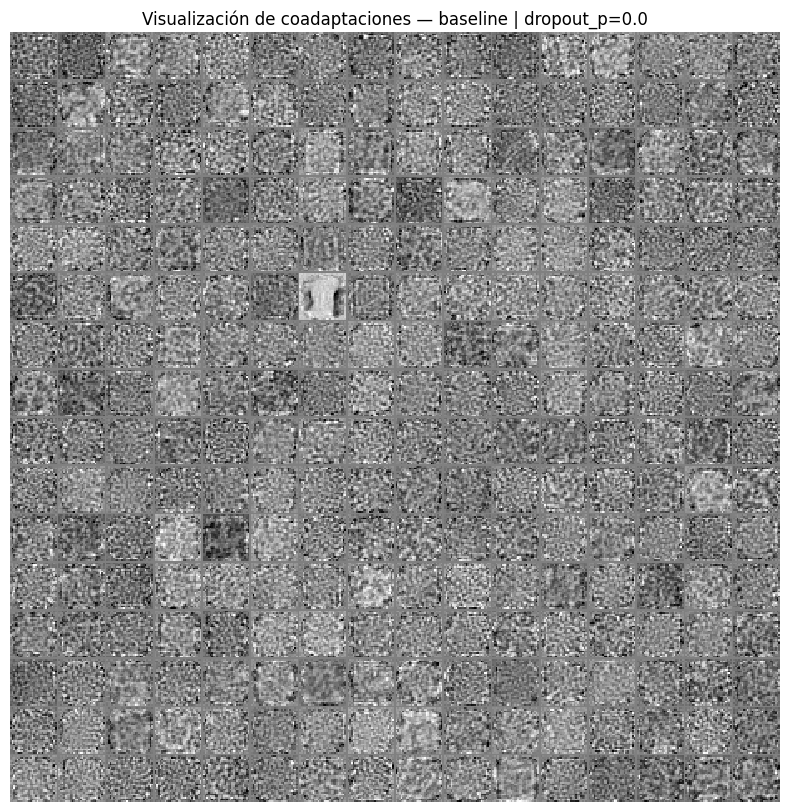

In [21]:
# =========================
# 12) Visualizar coadaptation para un único modelo
# =========================
# Descomentar cuando ya exista el modelo.

fig = plot_coadaptation_from_model_path(
    model_path=baseline_expected_path,
    save_path=baseline_expected_path.parent / 'coadaptation.png',
)


Saved: runs/autoencoder/6fa4a31ed05d/dropout_p0_5/coadaptation.png


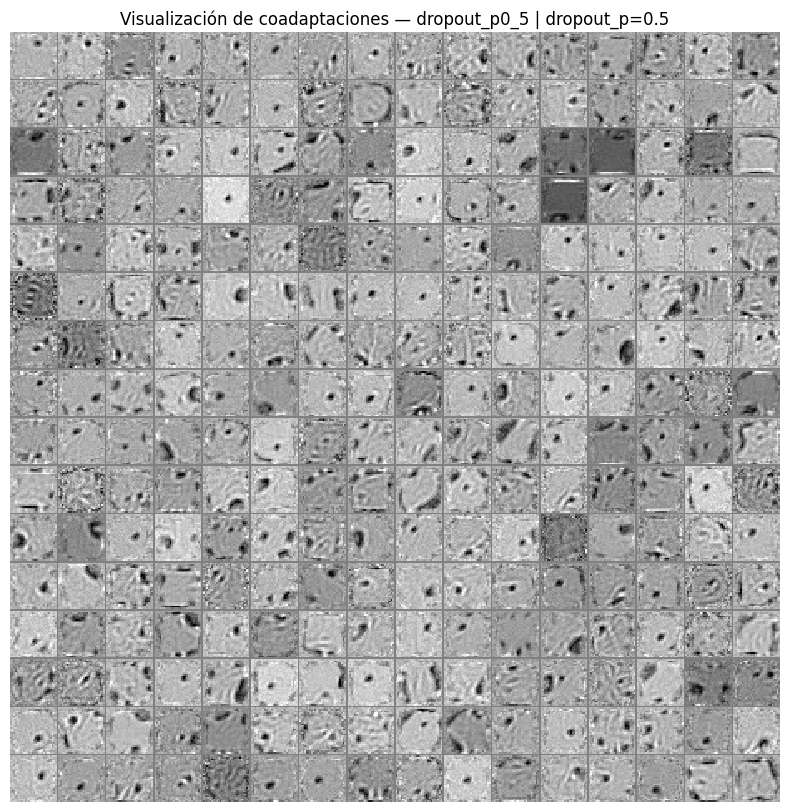

In [25]:
fig = plot_coadaptation_from_model_path(
    model_path=dropout_expected_path,
    save_path=dropout_expected_path.parent / 'coadaptation.png',
)

Saved: runs/autoencoder/6fa4a31ed05d/dropout_p0_5/sparsity.png


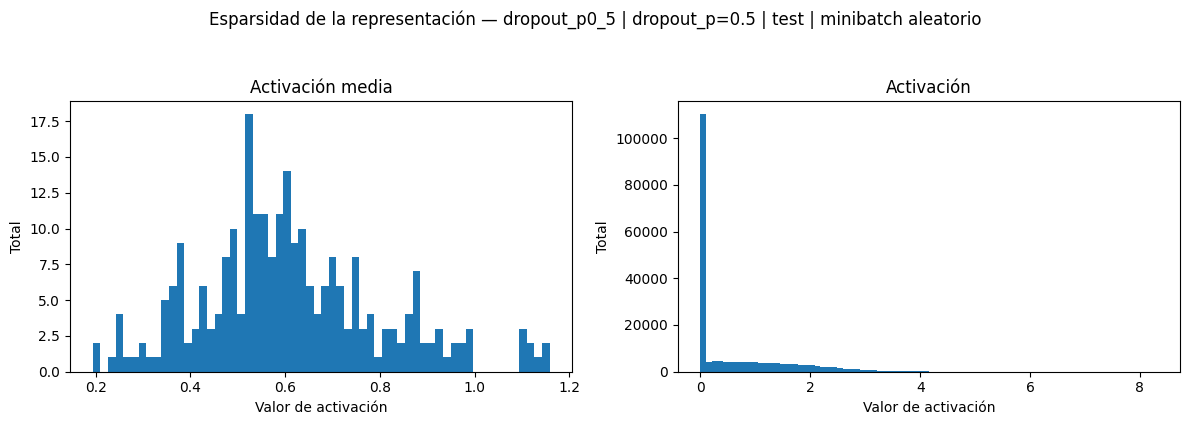

{
  "mean_activation_mean": 0.6111829876899719,
  "mean_activation_std": 0.19237907230854034,
  "all_activation_mean": 0.6111829280853271,
  "all_activation_std": 0.8945218920707703,
  "fraction_exact_zero": 0.5275181361607143,
  "fraction_gt_1": 0.2670151068239796,
  "fraction_gt_2": 0.10166214923469388
}


In [26]:
# =========================
# 13) Visualizar sparsity para un único modelo
# =========================
# Descomentar cuando ya exista el modelo.
# Por defecto usa un minibatch aleatorio del test set, fiel al procedimiento descrito.

fig, summary = plot_representational_sparsity_from_model_path(
    model_path=dropout_expected_path,
    split='test',
    batch_size=128,
    random_batch=True,
    seed=SEED,
    save_path=dropout_expected_path.parent / 'sparsity.png',
)


Saved: runs/autoencoder/638d7707aa98/baseline/coadaptation.png


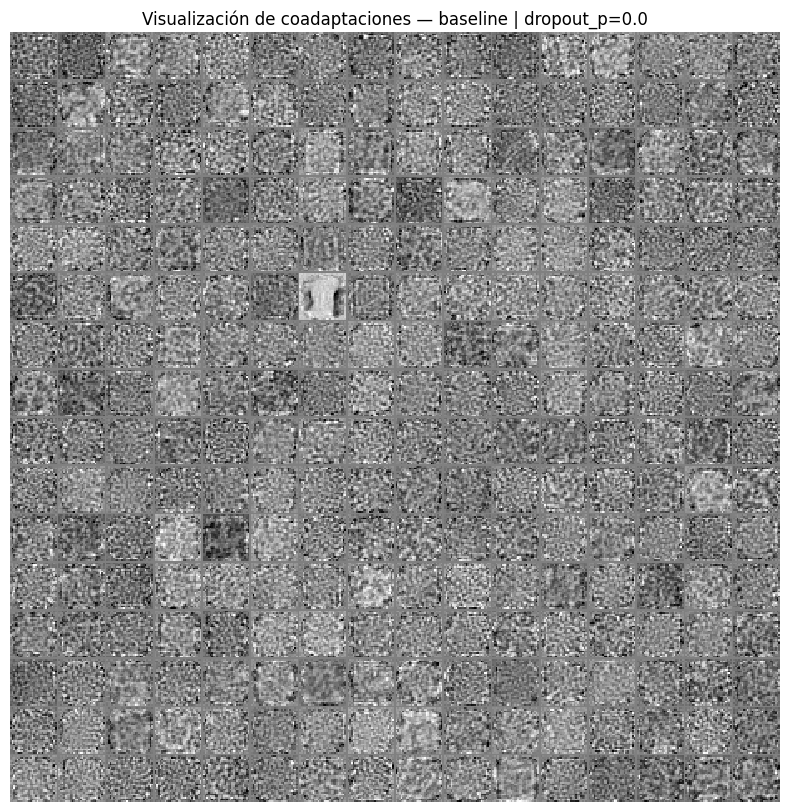

Saved: runs/autoencoder/638d7707aa98/baseline/sparsity.png


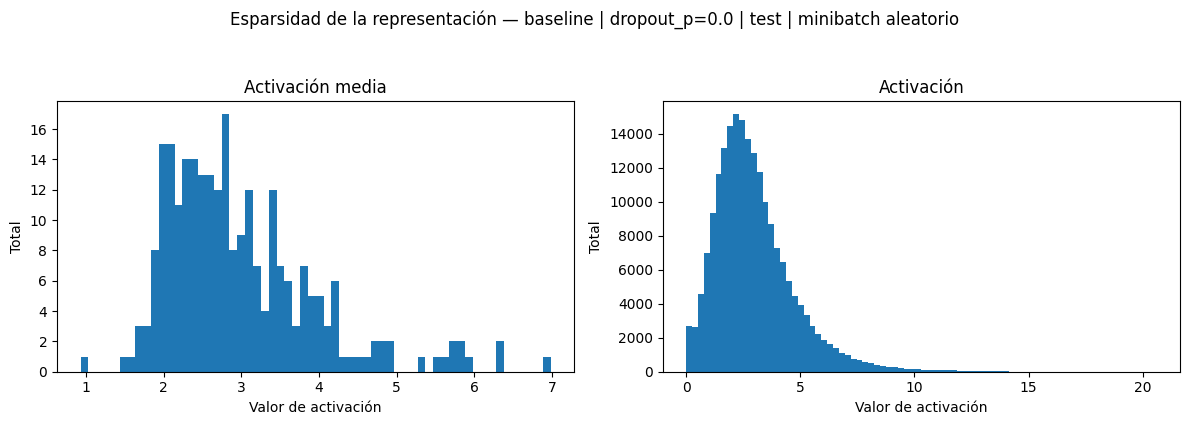

{
  "mean_activation_mean": 2.981870651245117,
  "mean_activation_std": 0.9713571071624756,
  "all_activation_mean": 2.981870651245117,
  "all_activation_std": 1.7620905637741089,
  "fraction_exact_zero": 0.007040218431122449,
  "fraction_gt_1": 0.920539700255102,
  "fraction_gt_2": 0.6906538982780612
}


In [28]:
# =========================
# 14) Helper: generar ambas figuras para UN modelo dado
# =========================

def generate_all_figures_for_model(model_path: str | Path):
    model_path = Path(model_path)
    out_dir = model_path.parent
    plot_coadaptation_from_model_path(
        model_path=model_path,
        save_path=out_dir / 'coadaptation.png',
        show=True,
    )
    plot_representational_sparsity_from_model_path(
        model_path=model_path,
        split='test',
        batch_size=512,
        random_batch=True,
        seed=SEED,
        save_path=out_dir / 'sparsity.png',
        show=True,
    )

# Uso:
generate_all_figures_for_model(baseline_expected_path)


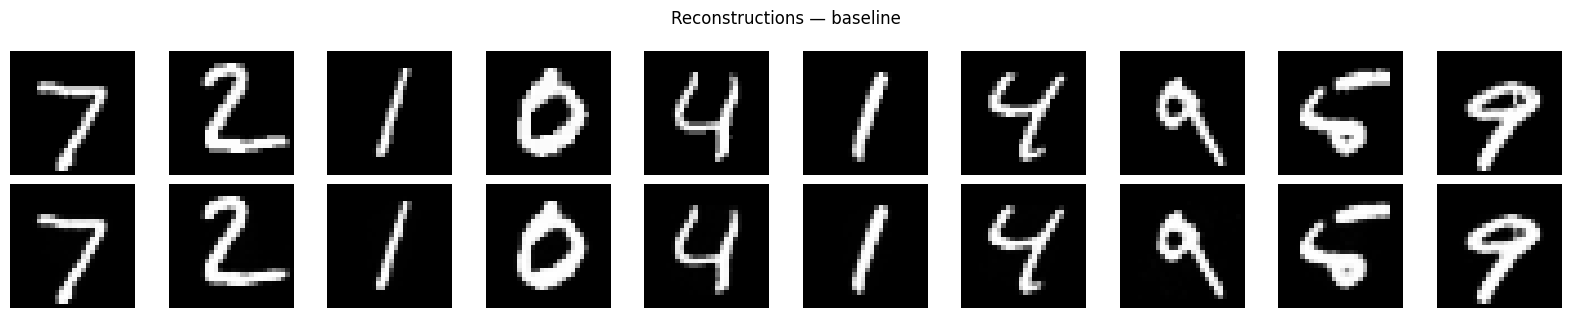

In [27]:
# =========================
# 15) Utilidad opcional: ver reconstrucciones
# =========================
@torch.no_grad()
def show_reconstructions(model_path: str | Path, n: int = 8):
    model, config, ckpt = load_model_from_path(model_path)
    _, test_loader = build_dataloaders(batch_size=max(n, 8))
    x, _ = next(iter(test_loader))
    x = x.to(DEVICE)
    recon, logits, h = model(x)
    recon = recon.view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.6*n, 3.2))
    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i, 0], cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Input')
    axes[1, 0].set_ylabel('Recon')
    plt.suptitle(f'Reconstructions — {config.model_name}')
    plt.tight_layout()
    plt.show()

# Uso:
show_reconstructions(baseline_expected_path, n=10)


In [ ]:
# =========================
# 16) Export rápido de resumen de corrida desde model path
# =========================

def read_metrics_from_model_path(model_path: str | Path):
    model_path = Path(model_path)
    metrics_path = model_path.parent / 'metrics.json'
    with open(metrics_path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    return payload

# Uso:
# print(json.dumps(read_metrics_from_model_path(baseline_expected_path), indent=2, ensure_ascii=False))


## Notas de fidelidad respecto del paper

- La arquitectura implementada es `784 -> 256 -> 784` con **ReLU** en la capa oculta y **dropout p=0.5** en la versión con dropout, siguiendo la descripción del paper. citeturn663853search0turn993831view2
- Para la visualización de sparsity, el paper indica que se toma **un minibatch aleatorio del test set**, y se grafican dos histogramas: **media de activación por unidad** y **activaciones** del mismo minibatch. Además, para el dropout autoencoder aclara que **no se escalan los pesos hacia abajo** al generar la figura. citeturn993831view2turn993831view3
- La visualización de “coadaptation” se implementa como mosaico de pesos del encoder, análogo a la figura de features aprendidas del paper. citeturn993831view0turn601219view0